In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np, pandas as pd
from tqdm import tqdm

#### Part 0: Obtaining stock data

In [2]:
tickers =\
[
    'XLP',
    'XLE',
    'XLK',
    'XLF',
    'XLV',
    'XLI',
    'XLB',
    'XLU'
]
start_date = dt.datetime(2000,1,1)
end_date = dt.datetime(2025,10,1)

stock_data = yf.download(tickers, start_date, end_date,auto_adjust=False)

[*********************100%***********************]  8 of 8 completed


In [3]:
stock_data = stock_data.loc[:,['Adj Close','Volume']]

In [4]:
# inspect missingness of the data
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6475 entries, 2000-01-03 to 2025-09-30
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, XLB)  6475 non-null   float64
 1   (Adj Close, XLE)  6475 non-null   float64
 2   (Adj Close, XLF)  6475 non-null   float64
 3   (Adj Close, XLI)  6475 non-null   float64
 4   (Adj Close, XLK)  6475 non-null   float64
 5   (Adj Close, XLP)  6475 non-null   float64
 6   (Adj Close, XLU)  6475 non-null   float64
 7   (Adj Close, XLV)  6475 non-null   float64
 8   (Volume, XLB)     6475 non-null   int64  
 9   (Volume, XLE)     6475 non-null   int64  
 10  (Volume, XLF)     6475 non-null   int64  
 11  (Volume, XLI)     6475 non-null   int64  
 12  (Volume, XLK)     6475 non-null   int64  
 13  (Volume, XLP)     6475 non-null   int64  
 14  (Volume, XLU)     6475 non-null   int64  
 15  (Volume, XLV)     6475 non-null   int64  
dtypes: float64(8), int64(8)


In [5]:
# split dfs to make it easier to work with
last_ret_idx = stock_data.columns.get_loc(('Adj Close', 'XLV'))
stock_data_prices = stock_data.iloc[:,:last_ret_idx+1]
stock_data_vol = stock_data.iloc[:,:last_ret_idx+1]     # TODO amend the column selection here
stock_data_prices.columns = stock_data_prices.columns.droplevel(0)
stock_data_vol.columns = stock_data_vol.columns.droplevel(0)

# create returns dataframe
returns_df = stock_data_prices.pct_change() 
returns_df.dropna(inplace = True)

In [6]:
# Load share outstanding data
XLP = pd.read_excel('ETF data/navhist-us-en-xlp.xlsx')
XLE = pd.read_excel('ETF data/navhist-us-en-xle.xlsx')
XLK = pd.read_excel('ETF data/navhist-us-en-xlk.xlsx')
XLF = pd.read_excel('ETF data/navhist-us-en-xlf.xlsx')
XLV = pd.read_excel('ETF data/navhist-us-en-xlv.xlsx')
XLI = pd.read_excel('ETF data/navhist-us-en-xli.xlsx')
XLB = pd.read_excel('ETF data/navhist-us-en-xlb.xlsx')
XLU = pd.read_excel('ETF data/navhist-us-en-xlu.xlsx')

In [7]:
def process_ETF_data(df):
    """
    Conducts preprocessing for the ETF DataFrames in order to simplify market cap calculation
    Inputs: df (pandas DataFrame): DataFrame from State Street containing Shares Outstanding
    Outputs: None. Manipulation is done in place
    """
    
    df.columns = df.loc[2,:]
    df = df.loc[3:df.index[-500]-1, :].copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.loc[:,['Date','Shares Outstanding']]
    return df

In [8]:
XLP = process_ETF_data(XLP)
XLP = XLP.rename(columns={"Shares Outstanding": "XLP_Shares Outstanding"})
XLE = process_ETF_data(XLE)
XLE = XLE.rename(columns={"Shares Outstanding": "XLE_Shares Outstanding"})
XLK = process_ETF_data(XLK)
XLK = XLK.rename(columns={"Shares Outstanding": "XLK_Shares Outstanding"})
XLF = process_ETF_data(XLF)
XLF = XLF.rename(columns={"Shares Outstanding": "XLF_Shares Outstanding"})
XLV = process_ETF_data(XLV)
XLV = XLV.rename(columns={"Shares Outstanding": "XLV_Shares Outstanding"})
XLI = process_ETF_data(XLI)
XLI = XLI.rename(columns={"Shares Outstanding": "XLI_Shares Outstanding"})
XLB = process_ETF_data(XLB)
XLB = XLB.rename(columns={"Shares Outstanding": "XLB_Shares Outstanding"})
XLU = process_ETF_data(XLU)
XLU = XLU.rename(columns={"Shares Outstanding": "XLU_Shares Outstanding"})

In [9]:
def merge_dataframes(ret_df, SO_df):
    return ret_df.merge(SO_df, on='Date', how='left') 

In [10]:
stock_data_prices = merge_dataframes(stock_data_prices, XLP)
stock_data_prices = merge_dataframes(stock_data_prices, XLE)
stock_data_prices = merge_dataframes(stock_data_prices, XLK)
stock_data_prices = merge_dataframes(stock_data_prices, XLF)
stock_data_prices = merge_dataframes(stock_data_prices, XLV)
stock_data_prices = merge_dataframes(stock_data_prices, XLI)
stock_data_prices = merge_dataframes(stock_data_prices, XLB)
stock_data_prices = merge_dataframes(stock_data_prices, XLU)

stock_data_prices.dropna(inplace=True)
stock_data_prices.isna().sum()

stock_data_prices = stock_data_prices[~stock_data_prices['XLP_Shares Outstanding'].apply(lambda x: isinstance(x, str))]
for column in stock_data_prices.columns[9:]:
    assert stock_data_prices[column].apply(lambda x: isinstance(x, int)).all(), "Not all values are integers"

In [12]:
stock_data_mktcap = pd.DataFrame()
stock_data_mktcap['Date'] = stock_data_prices['Date']
stock_data_mktcap['XLP'] = stock_data_prices['XLP'] * stock_data_prices['XLP_Shares Outstanding']
stock_data_mktcap['XLE'] = stock_data_prices['XLE'] * stock_data_prices['XLE_Shares Outstanding']
stock_data_mktcap['XLK'] = stock_data_prices['XLK'] * stock_data_prices['XLK_Shares Outstanding']
stock_data_mktcap['XLF'] = stock_data_prices['XLF'] * stock_data_prices['XLF_Shares Outstanding']
stock_data_mktcap['XLV'] = stock_data_prices['XLV'] * stock_data_prices['XLV_Shares Outstanding']
stock_data_mktcap['XLI'] = stock_data_prices['XLI'] * stock_data_prices['XLI_Shares Outstanding']
stock_data_mktcap['XLB'] = stock_data_prices['XLB'] * stock_data_prices['XLB_Shares Outstanding']
stock_data_mktcap['XLU'] = stock_data_prices['XLU'] * stock_data_prices['XLU_Shares Outstanding']
stock_data_mktcap.set_index("Date",inplace=True)
stock_data_mktcap = stock_data_mktcap.astype(float)
stock_data_mktcap.head()

,XLP,XLE,XLK,XLF,XLV,XLI,XLB,XLU
Date,,,,,,,,
2006-05-31,6.704463e+08,2.559777e+09,1.160275e+09,1.226331e+09,1.213989e+09,7.326536e+08,5.870635e+08,1.126087e+09
2006-06-01,6.740960e+08,2.430043e+09,1.180153e+09,1.223288e+09,1.221293e+09,7.402090e+08,5.934549e+08,1.143125e+09
2006-06-02,6.726920e+08,2.396115e+09,1.176176e+09,1.220243e+09,1.226056e+09,7.412883e+08,5.991152e+08,1.145420e+09
2006-06-05,6.631463e+08,2.311403e+09,1.166462e+09,1.182405e+09,1.207004e+09,7.253142e+08,5.915950e+08,1.131691e+09
2006-06-06,6.651119e+08,2.142707e+09,1.166462e+09,1.184906e+09,1.208989e+09,7.225081e+08,5.732040e+08,1.101892e+09


In [13]:
stock_data_prices.set_index("Date",inplace = True)
stock_data_prices = stock_data_prices.iloc[:,0:8]
stock_data_vol = stock_data_vol.loc[stock_data_prices.index[0]:,:]

In [14]:
industries = {'XLB': 'Buildings',
             'XLE': 'Energy',
             'XLF': 'Financials',
             'XLI': 'Industrials',
             'XLK': 'Technology',
             'XLP': 'Consumer Staples',
             'XLU': 'Utilities',
             'XLV': 'Healthcare'
             }

In [21]:
import importlib.util
import sys

# Load the module with importlib
spec = importlib.util.spec_from_file_location(
    "alpha_module", 
    "/Users/ju/Projects/00_SMU/mqf_practice/QF603_Quant_Analysis_Fin_Markets/Raymon_code/WorldQuant_alpha101_code-master/101Alpha_code_1.py"
)
alpha_module = importlib.util.module_from_spec(spec)
sys.modules["alpha_module"] = alpha_module
spec.loader.exec_module(alpha_module)

# Now you can use it
Alphas = alpha_module.Alphas

In [22]:
stock_data

Price       Adj Close                                                \
Ticker            XLB        XLE        XLF         XLI         XLK   
Date                                                                  
2000-01-03  14.595771  13.513021  11.186876   18.187748   41.366730   
2000-01-04  14.455253  13.258660  10.697835   17.685268   39.268074   
2000-01-05  15.052432  13.608417  10.613778   17.606451   38.685097   
2000-01-06  15.438837  14.133038  11.079897   17.842905   37.402599   
2000-01-07  15.430047  14.284060  11.263290   18.522732   38.055527   
...               ...        ...        ...         ...         ...   
2025-09-24  88.980003  90.339996  53.610001  152.250000  278.489990   
2025-09-25  87.820000  91.150002  53.470001  151.220001  278.000000   
2025-09-26  88.839996  91.989998  53.860001  152.580002  278.839996   
2025-09-29  89.180000  90.300003  54.130001  153.050003  280.329987   
2025-09-30  89.620003  89.339996  53.869999  154.229996  281.859985   

Price                                          Volume                      \
Ticker            XLP        XLU         XLV      XLB       XLE       XLF   
Date                                                                        
2000-01-03  12.305081  11.186379   20.612171   140500    380300   1185699   
2000-01-04  11.958582  10.848941   20.144442   258000    722200    885705   
2000-01-05  12.169860  11.122713   19.963732   102700    337800    717181   
2000-01-06  12.398049  11.103610   20.027517  1335000    133100    415832   
2000-01-07  13.184013  11.199115   20.272013   620100    468000    468149   
...               ...        ...         ...      ...       ...       ...   
2025-09-24  78.519997  86.250000  136.389999  5334800  17703100  23893400   
2025-09-25  77.769997  85.419998  134.130005  5538600  15943600  24757500   
2025-09-26  77.959999  86.809998  135.500000  4972300  20080800  30686100   
2025-09-29  78.110001  87.059998  135.899994  4689400  18837200  20713800   
2025-09-30  78.370003  87.209999  139.169998  4704100  23772400  32442200   

Price                                                        
Ticker          XLI       XLK       XLP       XLU       XLV  
Date                                                         
2000-01-03    82800    938100    634300    176700    246700  
2000-01-04   146900    545500    172000     93500     35300  
2000-01-05   129200   1906000    343600    273400    137600  
2000-01-06    54000   1670000    420800     34500     50000  
2000-01-07    32900    686000    337100     46200     22100  
...             ...       ...       ...       ...       ...  
2025-09-24  5938400   6735500  10634100   8658800   7471600  
2025-09-25  7145800  10674800  12046100   9344800  14099700  
2025-09-26  6958900   8267000  11547800   8116900  10071000  
2025-09-29  7177600   8053700  11490300   8565400   7735700  
2025-09-30  8211200   9107600  12306100  10980000  19313500  

[6475 rows x 16 columns]

#### Part 1: Factor construction

Start with raw stock data

- Core Alpha101-style technical factors
- Derived / custom factors

Chosen factors:

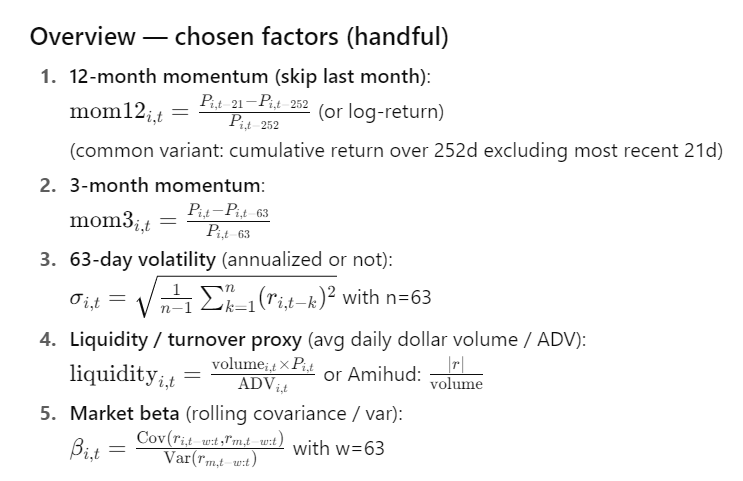

In [15]:
# define factor creation functions
def factor_mom(price_panel, lookback_days, skip_days=0):
    """
    Function that creates the momentum factor for each asset in the price_panel over a given lookback period.
    Inputs: price_panel (pandas DataFrame): DataFrame with tickers as cols and prices of assets in rows
            lookback_days (int): Number of days to look back for calculating momentum 
            skip_days (int): Number of recent days to skip when calculating momentum. Lets you avoid using 
                             today's / recent days in momentum calculation
    Outputs:DataFrame containing the momentum values for each stock and each date.
    """
    # shift function shifts data by specified days to compute relative price change over lookback period
    # e.g. lookback days = 30 means that the division will show the return over the past month
    # iloc removes NaN vals created by the shift
    p = price_panel
    return (p.shift(skip_days) / p.shift(lookback_days + skip_days) - 1).iloc[lookback_days + skip_days :].copy()

def factor_vol(returns_panel, window=63):
    """
    Function that creates the rolling volatility factor for each asset in the price panel over a sliding window.
    Inputs: price_panel (pandas DataFrame): DataFrame with tickers as cols and prices of assets in rows
            window (int): The length of the sliding window over which to calculate rolling vol
    Outouts: DataFrame containing rolling vol values for each stock and each date
    """
    # rolling creates a sliding window of "window" length. The std function then calcs standard deviation of
    # the values in this sliding window
    # .iloc removes the NaN values created by using the sliding window
    return returns_panel.rolling(window).std().iloc[window:].copy()

def factor_adv(volume_panel, price_panel, window=63):
    """
    Function that calculates the average daily dollar value of trades for days in a sliding window
    Inputs: price_panel (pandas DataFrame): DataFrame with tickers as cols and prices of assets in rows
            volume_panel(pandas DataFrame): DataFrame with tickers as cols and volume of assets traded in rows
            window (int): The length of the sliding window over which to calculate mean asset value traded
    Outputs:DataFrame containing rolling dollar value traded for each stock and each date
    """
    return (volume_panel * price_panel).rolling(window).mean().iloc[window:].copy()

def factor_liquidity_amihud(returns_panel, volume_panel, price_panel, window=63):
    """
    Named the amihud liquidity measure, which is a representation of the liquidity of a stock.
    Lower values suggest higher liquidity while higher values suggest lower liquidity.
    Inputs: returns_panel (pandas DataFrame):DataFrame with tickers as cols and returns of assets in rows
            price_panel (pandas DataFrame): DataFrame with tickers as cols and prices of assets in rows
            volume_panel(pandas DataFrame): DataFrame with tickers as cols and volume of assets traded in rows
            window (int): The length of the sliding window over which to calculate mean asset value traded
    Outputs:DataFrame containing the rolling amihud liquidity measure for each stock and each date
    """
    # amihud: |r| / dollar volume (use small epsilon)
    DV_panel = price_panel * volume_panel
    return (returns_panel.abs() / (DV_panel.replace(0, np.nan))).rolling(window).mean().iloc[window:].copy()

def compute_beta(returns_panel, market_returns, window=63):
    """
    Calculate the rolling beta of each asset relative to the market.
    Beta is computed as the rolling covariance of asset returns and market returns,
    divided by the rolling variance of market returns.
    Inputs: returns_panel (pandas DataFrame): A DataFrame of asset returns (dates x tickers)
            market_returns (pandas Series): The market returns (dates)
            window (int): The length of the rolling window to calculate the beta
    Outputs:
            betas (pandas DataFrame): The rolling betas for each asset (dates x tickers)
    """
    betas = pd.DataFrame(index=returns_panel.index, columns=returns_panel.columns, dtype=float)
    for i in range(window, len(returns_panel)):
        sl = slice(i-window+1, i+1)
        rsub = returns_panel.iloc[sl]
        rm_sub = market_returns.iloc[sl]
        denom = rm_sub.var(ddof=1)
        if np.isclose(denom, 0):
            betas.iloc[i] = 0.0
        else:
            # cov for each column
            cov = rsub.apply(lambda col: np.cov(col.fillna(0), rm_sub.fillna(0))[0,1])
            betas.iloc[i] = cov / denom
    return betas.iloc[window-1:].copy()

In [ ]:
# factor application function
def build_factor_table(price_panel, volume_panel, market_cap_panel, industry_map):
    """
    Build a unified factor table (long format) from price, volume, and metadata panels.
    
    Inputs: price_panel (pandas DataFrame): prices (dates x tickers)
            volume_panel (pandas DataFrame): volume (dates x tickers)
            market_cap_panel (pandas DataFrame): market cap (dates x tickers)
            industry_map (dict): mapping {ticker: industry}
    Output: table (pandas DataFrame): with columns:
            ['date','ticker','mom12','mom3','vol63','amihud','beta63','market_cap','industry']
    """

    # ---------- Step 1: Compute daily returns ----------
    returns_panel = price_panel.pct_change().fillna(0)
    # print(returns_panel.head(20))
    # print(volume_panel.head(20))
    # print(price_panel.head(20))

    # ---------- Step 2: Compute factors ----------
    mom12 = factor_mom(price_panel, lookback_days=252, skip_days=21)
    mom3  = factor_mom(price_panel, lookback_days=63, skip_days=0)
    vol63 = factor_vol(returns_panel, window=63)
    amihud = factor_liquidity_amihud(returns_panel, volume_panel, price_panel, window=63)

    # compute market returns (cap-weighted average of returns)
    cap = market_cap_panel.fillna(method='ffill')
    market_returns = (returns_panel * cap).sum(axis=1) / cap.sum(axis=1)
    beta63 = compute_beta(returns_panel, market_returns, window=63)

    # ---------- Step 3: Align all factor indices ----------
    common_idx = (
        mom12.index
        .intersection(mom3.index)
        .intersection(vol63.index)
        .intersection(amihud.index)
        .intersection(beta63.index)
        .intersection(market_cap_panel.index)
    )

    mom12 = mom12.loc[common_idx]
    mom3 = mom3.loc[common_idx]
    vol63 = vol63.loc[common_idx]
    amihud = amihud.loc[common_idx]
    beta63 = beta63.loc[common_idx]
    market_cap_panel = market_cap_panel.loc[common_idx]
    # print(amihud.head(20))
    # ---------- Step 4: Helper to reshape panels to long format ----------
    def to_long(df, name):
        return (
            df.stack()
              .rename(name)
              .reset_index()
              .rename(columns={'level_0': 'Date', 'level_1': 'ticker'})
        )

    # ---------- Step 5: Stack and merge ----------
    dfs = [
        to_long(mom12, 'mom12'),
        to_long(mom3, 'mom3'),
        to_long(vol63, 'vol63'),
        to_long(amihud, 'amihud'),
        to_long(beta63, 'beta63'),
        to_long(market_cap_panel, 'market_cap'),
    ]

    from functools import reduce
    table = reduce(lambda left, right: pd.merge(left, right, on=['Date', 'ticker'], how='outer'), dfs)

    # ---------- Step 6: Add industry classification ----------
    industry_df = (
        pd.DataFrame.from_dict(industry_map, orient='index', columns=['industry'])
        .reset_index()
        .rename(columns={'index': 'ticker'})
    )
    table = table.merge(industry_df, on='ticker', how='left')

    # ---------- Step 7: Clean up ----------
    # Drop rows where essential factors are missing
    table = table.dropna(subset=['mom12', 'mom3', 'vol63', 'amihud', 'beta63', 'market_cap'])
    table = table.sort_values(['Date', 'ticker']).reset_index(drop=True)

    return table

In [17]:
factor_table = build_factor_table(stock_data_prices, stock_data_vol, stock_data_mktcap, industries)

                 XLB       XLE       XLF       XLI       XLK       XLP  \
Date                                                                     
2006-05-31  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2006-06-01  0.010887  0.002700  0.011628  0.010313  0.017131  0.005444   
2006-06-02  0.009539  0.014902  0.005747  0.001458 -0.003369 -0.002083   
2006-06-05 -0.029869 -0.031488 -0.016241 -0.021549 -0.014969 -0.014190   
2006-06-06 -0.008483 -0.000913 -0.002446 -0.003869  0.000000  0.002964   
2006-06-07 -0.022814 -0.038391  0.003371 -0.011055 -0.013725 -0.000422   
2006-06-08 -0.003242  0.014069  0.001833  0.000604 -0.004970  0.003379   
2006-06-09 -0.005205 -0.010124 -0.003353 -0.008454 -0.003997  0.000842   
2006-06-12 -0.015697 -0.020454 -0.011012 -0.012485 -0.018556 -0.005887   
2006-06-13 -0.016944 -0.029583 -0.019487 -0.003083  0.001022 -0.003384   
2006-06-14  0.013180  0.025702 -0.005993  0.008661  0.006637  0.004244   
2006-06-15  0.033356  0.038073  0.0222

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_78737/816774047.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cap = market_cap_panel.fillna(method='ffill')


The output data shows the factor value for each ticker on each date. 

| Column         | Meaning                                     |
| -------------- | ------------------------------------------- |
| **date**       | Trading date (index of the original panels) |
| **ticker**     | Stock symbol                                |
| **mom12**      | 12-month momentum (excluding last month)    |
| **mom3**       | 3-month momentum                            |
| **vol63**      | 63-day rolling volatility                   |
| **amihud**     | Amihud illiquidity measure                  |
| **beta63**     | 63-day rolling market beta                  |
| **market_cap** | Latest market capitalization                |
| **industry**   | Industry classification                               |


Notes:
- Market capitalisation is included in the data pipeline even though it itself is not an alpha factor. Market cap represents firm size, which is one of the strongest systematic risk factors in asset pricing.
- If size is not controlled for, many factors will simply be disguised size effects (e.g. if momentum or liquidity factor loads heavily on small caps, it looks predictive, but the model would simply be leaning into the size bias - small caps having higher vol, higher momentum and lower liquidity).
- The eventual size neutralization in the pipeline is: Regressing each factor on log(MarketCap) and (log(MarketCap))<sup>2</sup> per date, then using residuals as the pure alpha.

In [20]:
# Calculation of forward returns for the IC calculation
def compute_forward_returns(price_panel, horizon=21, gap=1):
    """
    Compute forward returns for each asset over the next `horizon` days,
    optionally skipping `gap` days to avoid lookahead bias.
    Inputs: price_panel (pandas DataFrame): prices (dates x tickers)
            horizon (int): number of days to look ahead for return calc
            gap (int): number of days to skip between features and start of return window
    Output: pandas DataFrame: forward returns aligned with the current feature date
    """
    # Example: horizon=21, gap=1 → return over days t+1 ... t+21
    return (price_panel.shift(-(gap + horizon - 1)) / price_panel.shift(-gap) - 1)

In [21]:
forward_rets = compute_forward_returns(stock_data_prices)
forward_rets_long = (
    forward_rets
    .stack()
    .rename('fwd_return')
    .reset_index()
    .rename(columns={'level_0': 'date', 'level_1': 'ticker'})
)

In [22]:
factor_table = factor_table.merge(forward_rets_long, on=['Date','ticker'], how='left')

#### Part 3: Bias correction / neutralisation

Raw factors are not pure predictors, they often capture structural biases like:

- Industry effects (tech stocks move together)

- Size effects (small caps have higher volatility)

- Market-wide trends (momentum correlates with beta)

Neutralization ensures your factor’s correlation with forward returns isn’t just due to those broad effects.

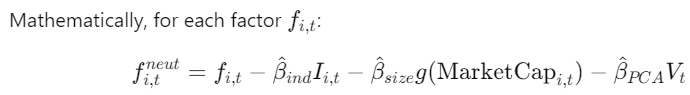

Stage 1. Identify systematic risk factors (via PCA)

Compute correlation matrix of factors.

Extract top K eigenvectors (principal components) representing “market-wide” common movements.

Optional: project factors orthogonally to remove those common components:
​
![image.png](attachment:ed279968-c4f5-4c21-b302-50b718d4710c.png)

Stage 2: Industry neutralisation

Regress each factor cross-sectionally on industry dummy variables:

![image.png](attachment:dde99fde-80d3-420e-8ff6-a12678a4b7fc.png)

Use robust regression (e.g., Huber, ridge) to avoid outlier distortion.

Stage 3: Size neutralisation (market cap bias)

Fit a log-linear model to remove linear and quadratic size effects

Stage 4: Adaptive neutralisation strength

In high-volatility regimes, use stronger neutralization (Du eq. 8):

![image.png](attachment:cc901f04-7497-40fb-9ca0-2b356a48c1cb.png)

Stage 5: Standardisation

After all neutralisation: Cross-sectionally z-score each factor (mean 0, std 1 per day).
This ensures no factor dominates due to scale.

In [41]:
# Neutralisation function
def neutralize_cross_sectional(table, factor_cols, industry_col='industry', cap_col='market_cap', variance_threshold=0.95, ridge_alpha=1.0):
    """
    table: long-format df with columns ['date','ticker', factor_cols..., industry_col, cap_col]
    factor_cols: list of factor column names to neutralize
    variance_threshold: the amount of variance to explain via PCA, e.g., 0.95 means 95% variance
    steps:
      1) for each date, create cross-sectional matrix F (n_stocks x n_factors)
      2) optional: PCA decomposition on F (correlation or covariance) and remove projection onto components that explain the desired variance threshold
      3) industry neutralization: regress each factor on industry dummies (ridge) and subtract predicted
      4) size neutralization: regress residual on log(market_cap) and (log(market_cap))^2
      5) z-score each factor cross-sectionally (per date)
    returns: table with neutralized factor columns appended as e.g. mom12_neut
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        # TODO WHY DO WE NEED TO SKIP IF ITS LESS THAN 10
        # if slice_df.shape[0] < 10:
        #     # too few names - skip neutralization but still zscore
        #     for f in factor_cols:
        #         slice_df[f + '_neut'] = zscore(slice_df[f].fillna(0).values)
        #     out_rows.append(slice_df)
        #     continue
        

        # Build factor matrix F (n_stocks x n_factors)
        F = slice_df[factor_cols].values
        
        # --- PCA removal based on variance threshold
        if variance_threshold is not None and variance_threshold > 0:
            # Standardize the factors (columns mean=0, variance=1)
            scaler = StandardScaler(with_mean=True, with_std=False)
            Fc = scaler.fit_transform(F)
            
            # Perform PCA and get explained variance ratio
            pca = PCA()
            pca.fit(Fc)
            explained_variance_ratio = pca.explained_variance_ratio_

            # Find the number of components that explain at least `variance_threshold` amount of variance
            cumulative_variance = np.cumsum(explained_variance_ratio)
            n_pcs_remove = np.argmax(cumulative_variance >= variance_threshold) + 1  # Get the number of PCs required
            
            # If no components are required to meet the threshold, skip PCA
            # if n_pcs_remove > 0:
            #     pcs = pca.transform(Fc)  # Project data onto the principal components
            #     reconstructed = pca.inverse_transform(pcs[:, :n_pcs_remove])  # Reconstruct the part to remove
            #     F = Fc - reconstructed
            # else:
            #     # If n_pcs_remove is 0, we leave the data unchanged
            #     F = Fc
            # TODO replace above with this to solve the dimension issue
            if n_pcs_remove > 0:
                pcs = pca.transform(Fc)  # Project data onto the principal components
                # Zero out the first n_pcs_remove components
                pcs_filtered = pcs.copy()
                pcs_filtered[:, :n_pcs_remove] = 0
                # Reconstruct using the remaining components
                F = pca.inverse_transform(pcs_filtered)
            else:
                F = Fc

        # Build industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        
        # Regress each factor on industry dummies (ridge regression)
        X_ind = industries.values
        X_size = np.column_stack([np.log(slice_df[cap_col].values + 1e-9), np.log(slice_df[cap_col].values + 1e-9)**2])
        
        # Industry regression (Ridge to regularize)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        F_ind_neut = np.zeros_like(F)
        for j in range(F.shape[1]):
            y = F[:, j]
            # print(X_ind, y)
            ridge.fit(X_ind, y)
            y_hat = ridge.predict(X_ind)
            resid = y - y_hat
            F_ind_neut[:, j] = resid

        # Size neutralization: regress residual on log(cap) and squared
        F_size_neut = np.zeros_like(F_ind_neut)
        ridge2 = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F_ind_neut.shape[1]):
            y = F_ind_neut[:, j]
            ridge2.fit(X_size, y)
            y_hat = ridge2.predict(X_size)
            resid = y - y_hat
            F_size_neut[:, j] = resid

        # Now z-score each column cross-sectionally
        F_z = (F_size_neut - np.nanmean(F_size_neut, axis=0)) / (np.nanstd(F_size_neut, axis=0) + 1e-9)

        # Attach results
        for idx, ticker in enumerate(slice_df['ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        out_rows.append(slice_df)

    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','ticker']).reset_index(drop=True)
    return out_df

In [42]:
factor_names = list(factor_table.columns[2:7])

neut_df = neutralize_cross_sectional(
    factor_table,
    factor_names,
    industry_col='industry',
    cap_col='market_cap')
neut_df

Neutralizing per date: 100%|██████████| 4592/4592 [00:19<00:00, 234.90it/s]


,Date,ticker,mom12,mom3,vol63,amihud,beta63,market_cap,industry,fwd_return,mom12_neut,mom3_neut,vol63_neut,amihud_neut,beta63_neut
0,2007-07-02,XLB,0.322167,0.086630,0.010073,1.161131e-05,1.155246,8.843104e+08,Buildings,-0.036686,1.154424,1.154456,0.686321,-0.508088,-1.154736
1,2007-07-02,XLE,0.257386,0.156791,0.011710,6.447174e-06,1.450313,2.757365e+09,Energy,-0.027279,-0.067570,-0.067530,1.025380,-0.112991,0.067191
2,2007-07-02,XLF,0.190915,0.039362,0.008214,1.401272e-05,0.994377,1.177771e+09,Financials,-0.096169,-1.929743,-1.929781,-0.745023,1.171908,1.930115
3,2007-07-02,XLI,0.177173,0.107029,0.006838,7.787599e-06,0.796982,9.220352e+08,Industrials,0.002525,0.144415,0.144411,-0.113617,-0.481462,-0.144380
4,2007-07-02,XLK,0.265269,0.102309,0.006594,1.471035e-05,0.809191,1.791105e+09,Technology,-0.007692,1.471653,1.471575,-2.227009,0.984028,-1.470896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36731,2025-09-30,XLI,0.193388,0.046329,0.006972,2.475436e-07,1.119597,2.385568e+10,Industrials,NaN,0.602938,-0.603754,-1.126339,-1.137548,0.605343
36732,2025-09-30,XLK,0.187702,0.124526,0.008566,9.967219e-08,1.197810,9.019686e+10,Technology,NaN,-0.871161,0.870520,0.050274,-1.200577,-0.869266
36733,2025-09-30,XLP,0.002459,-0.037475,0.006407,7.897064e-07,0.233566,1.609891e+10,Consumer Staples,NaN,0.842761,-0.843536,-1.257441,-0.110178,0.845044
36734,2025-09-30,XLU,0.152579,0.071480,0.007899,9.150198e-07,0.507152,2.128135e+10,Utilities,NaN,-1.041929,1.042096,0.869280,-0.116108,-1.042418


In [43]:
df = neut_df[neut_df['Date']==neut_df['Date'][2000]].copy()
corr_before = df['mom3'].corr(df['market_cap'])
corr_after = df['mom3_neut'].corr(df['market_cap'])
print(corr_before, corr_after)

-0.15586740281070094 -0.06065616899197368


In [44]:
# Sanity checks to make sure the factors have been properly neutralized
#log_market_cap = np.log(neut_df['market_cap'])

print(f'The mean of mom12_neut is {neut_df['mom12_neut'].mean()}. It should be close to 0')
print(f'The mean of mom3_neut is {neut_df['mom3_neut'].mean()}. It should be close to 0')
print(f'The std of mom12_neut is {neut_df['mom12_neut'].std()}. It should be close to 1')
print(f'The std of mom3_neut is {neut_df['mom3_neut'].std()}. It should be close to 1')

per_date_corrs = neut_df.groupby('Date').apply(
    lambda df: df['mom12_neut'].corr(df['market_cap'])
)
print(per_date_corrs.mean())

#for neut_factor in factor_names[:2]:
#    name = neut_factor + "_neut"
#    print(f'Correlation between {neut_factor} and log market cap is: {neut_df[name].corr(log_market_cap)}. It should be close to 0')
    #print(f'Correlation between {neut_factor} and industry is: {neut_df[name].corr(neut_df['industry'])}. It should be close to 0')

The mean of mom12_neut is -1.8435214640171642e-18. It should be close to 0
The mean of mom3_neut is -1.5095720840599567e-18. It should be close to 0
The std of mom12_neut is 1.0000074837231556. It should be close to 1
The std of mom3_neut is 1.0000117334132845. It should be close to 1
-0.006742951501680827


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_78737/3999400281.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_date_corrs = neut_df.groupby('Date').apply(


#### Part 3: Factor quality filtering

Before neutralization, you remove unstable or low-quality factors:

| Metric                           | Meaning                          | Threshold / Use                    |    |       |
| -------------------------------- | -------------------------------- | ---------------------------------- | -- | ----- |
| **Information Coefficient (IC)** | corr(factor, next-period return) | keep if                            | IC | >0.02 |
| **IC stability**                 | std(IC) over time                | remove if too high                 |    |       |
| **Decay**                        | how fast IC drops with horizon   | remove if rapid                    |    |       |
| **Turnover**                     | factor changes too quickly?      | penalize high turnover             |    |       |
| **Correlation matrix**           | inter-factor correlations        | cluster & keep top of each cluster |    |       |


This section determines the quality of the factors by calculating the Information Coefficient (IC) for each factor, which is the cross sectional correlation between a factor's values and next-period returns for each date.

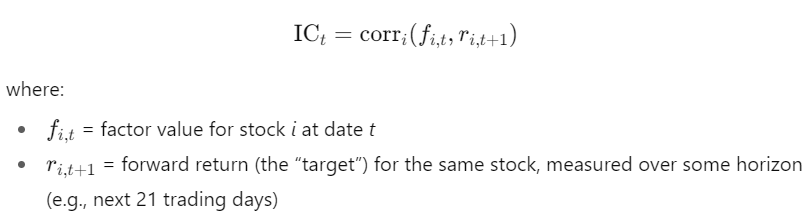

In [45]:
# Function to compute information coefficient
def compute_ic(table, factor_col_neut, forward_return_col='fwd_return'):
    """
    
    """
    # compute pearson (or spearman) cross-sectional correlation per date between factor and forward return
    dates = table['Date'].unique()
    ic_series = []
    for dt in dates:
        s = table[table['Date']==dt]
        if s.shape[0] < 5:
            ic_series.append(np.nan)
            continue
        a = s[factor_col_neut].values
        b = s[forward_return_col].values
        # use spearman or pearson
        try:
            rho = np.corrcoef(a, b)[0,1]
        except Exception:
            rho = np.nan
        ic_series.append(rho)
    return pd.Series(ic_series, index=dates)

In [31]:
neut_factor_names = list(neut_df.columns[10:])
ICs_series = [compute_ic(neut_df, neut_factor) for neut_factor in neut_factor_names]
ICs_df = pd.concat(ICs_series, axis=1)
ICs_df.columns = [f'{value}' for value in neut_factor_names]
ICs_df = ICs_df.rename(columns={"mom12_neut": "mom12",
                               "mom3_neut": "mom3",
                               "vol63_neut":"vol63",
                               "amihud_neut":"amihud",
                               "beta63_neut":"beta63"})
display(ICs_df)

,mom12,mom3,vol63,amihud,beta63
2007-07-02,0.666984,0.666984,-0.085203,-0.104916,-0.666985
2007-07-03,0.282682,0.379938,-0.117699,-0.111910,-0.561869
2007-07-05,0.386317,0.332028,-0.159268,-0.090512,-0.603755
2007-07-06,0.269814,-0.052288,-0.023037,0.146112,-0.180884
2007-07-09,0.110436,-0.068875,0.038754,0.203744,-0.014329
...,...,...,...,...,...
2025-09-24,NaN,NaN,NaN,NaN,NaN
2025-09-25,NaN,NaN,NaN,NaN,NaN
2025-09-26,NaN,NaN,NaN,NaN,NaN
2025-09-29,NaN,NaN,NaN,NaN,NaN


In [32]:
# NaNs equal to forward returns window
ICs_df.isna().sum()

mom12     21
mom3      21
vol63     21
amihud    21
beta63    21
dtype: int64

Each IC series is a time series of daily correlations between the neutralized factor values and the forward returns over the 21-day horizon. It is a measure of, on each day, how well the factor's ranking predicted the cross-sectional return ranking over the next period 

Interpretation of mean ICs

| Mean IC    | Typical interpretation                  |
| ---------- | --------------------------------------- |
| > 0.05     | Very strong factor (rare)               |
| 0.02–0.05  | Good, likely tradable                   |
| 0.005–0.02 | Weak but possibly useful in combination |
| ~0         | Noise / no predictive power             |
| < 0        | Inverted signal (could short it)        |


In [33]:
ic_summary = []
for series in ICs_df.columns:
    ic_summary.append({
        'Factor': series,
        'Mean IC': ICs_df[series].mean(),
        'Std IC': ICs_df[series].std(),
        'Information ratio': ICs_df[series].mean() / ICs_df[series].std(),
        'Hit ratio': (ICs_df[series] > 0).mean()
    })
ICs_summary = pd.DataFrame(ic_summary)
display(ICs_summary)

,Factor,Mean IC,Std IC,Information ratio,Hit ratio
0,mom12,-0.010684,0.369180,-0.028941,0.482578
1,mom3,0.020153,0.376731,0.053496,0.520906
2,vol63,-0.053158,0.355631,-0.149474,0.440767
3,amihud,-0.015551,0.331281,-0.046942,0.481490
4,beta63,-0.001044,0.369518,-0.002826,0.503267


In [34]:
# Selection of top factors


Factor weighting based on IC:

Equal weighting

- All factors contribute equally, regardless of IC
- The composite alpha represents a simple average of all factors. Negative IC factors still contribute with their original sign.
- Simple and robust, avoids “overfitting” noisy ICs but ignores differences in predictive power

Absolute weighting

- Each factor contributes proportional to the magnitude of its predictive power, ignoring sign. This means that weightages are calculated using absolute value of the ICs, but the sign on the factors themselves is not changed. 
- Factors with stronger predictive strength (positive or negative) get more weight. Negative IC factors are treated as strong predictors, but their direction is not flipped, so their contribution may partially cancel positive IC factors.
- Emphasizes stronger predictors but can reduce signal if positively correlated factors have opposing signs.

Sign-flipped IC weighting

- Each factor contributes proportional to the magnitude of its predictive power, ignoring sign. This means that weightages are calculated using absolute value of the ICs, and the sign on the factors themselves ARE changed to positive as well. 
- The composite alpha now represents a coherent long-short signal, where every factor contributes positively to predicting future returns.
- Avoids cancellation of factors with opposing signs.
- It preserves predictive signal and reduces cancellation, but assumes past negative IC will continue to invert predictively; slightly less conservative.

When to use each:

- Equal weighting: small factor set, noisy IC estimates, want robustness.

- Absolute IC: medium factor set, confident in magnitude of ICs, don’t mind partial cancellation.

- Sign-flipped IC: when factors are few and some have negative ICs, or when you want to maximize the magnitude of your composite signal.

In [35]:
# build composite alpha function  builds a composite alpha column (the final signal) from the ICs of each factor combined with its weightage
# Weighting is meant to combine factors so that more predictive factors contribute more to the composite alpha
# The coding here uses absolute IC weighting and has parameterisation for equal weighting
def build_composite_alpha(table_neut, factor_cols, ic_summary=None, weighted=False):
    cols_neut = [f + '_neut' for f in factor_cols]
    df = table_neut.copy()
    
    # Define weights
    if weighted and ic_summary is not None:
        weights = np.array([ic_summary.get(f, 0.0) for f in factor_cols])
        weights /= np.sum(np.abs(weights)) + 1e-12
    else:
        weights = np.ones(len(factor_cols)) / len(factor_cols)
    
    # Weighted combination (row-wise dot product)
    df['composite_alpha'] = df[cols_neut].fillna(0).dot(weights)
    
    # Z-score within each date
    df['composite_alpha'] = (df.groupby('Date')['composite_alpha'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9)))
    return df

In [36]:
neut_df.head(1)

,Date,ticker,mom12,mom3,vol63,amihud,beta63,market_cap,industry,fwd_return,mom12_neut,mom3_neut,vol63_neut,amihud_neut,beta63_neut
0,2007-07-02,XLB,0.322167,0.08663,0.010073,0.000012,1.155246,8.843104e+08,Buildings,-0.036686,1.154424,1.154456,0.686321,-0.508088,-1.154736


In [37]:
# used equal weight for now. 
table_combined = build_composite_alpha(
    neut_df,
    factor_cols=factor_names
)

In [38]:
table_combined

,Date,ticker,mom12,mom3,vol63,amihud,beta63,market_cap,industry,fwd_return,mom12_neut,mom3_neut,vol63_neut,amihud_neut,beta63_neut,composite_alpha
0,2007-07-02,XLB,0.322167,0.086630,0.010073,1.161131e-05,1.155246,8.843104e+08,Buildings,-0.036686,1.154424,1.154456,0.686321,-0.508088,-1.154736,1.365998
1,2007-07-02,XLE,0.257386,0.156791,0.011710,6.447174e-06,1.450313,2.757365e+09,Energy,-0.027279,-0.067570,-0.067530,1.025380,-0.112991,0.067191,0.865789
2,2007-07-02,XLF,0.190915,0.039362,0.008214,1.401272e-05,0.994377,1.177771e+09,Financials,-0.096169,-1.929743,-1.929781,-0.745023,1.171908,1.930115,-1.540439
3,2007-07-02,XLI,0.177173,0.107029,0.006838,7.787599e-06,0.796982,9.220352e+08,Industrials,0.002525,0.144415,0.144411,-0.113617,-0.481462,-0.144380,-0.462004
4,2007-07-02,XLK,0.265269,0.102309,0.006594,1.471035e-05,0.809191,1.791105e+09,Technology,-0.007692,1.471653,1.471575,-2.227009,0.984028,-1.470896,0.235138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36731,2025-09-30,XLI,0.193388,0.046329,0.006972,2.475436e-07,1.119597,2.385568e+10,Industrials,NaN,0.602938,-0.603754,-1.126339,-1.137548,0.605343,-0.896728
36732,2025-09-30,XLK,0.187702,0.124526,0.008566,9.967219e-08,1.197810,9.019686e+10,Technology,NaN,-0.871161,0.870520,0.050274,-1.200577,-0.869266,-1.091733
36733,2025-09-30,XLP,0.002459,-0.037475,0.006407,7.897064e-07,0.233566,1.609891e+10,Consumer Staples,NaN,0.842761,-0.843536,-1.257441,-0.110178,0.845044,-0.282822
36734,2025-09-30,XLU,0.152579,0.071480,0.007899,9.150198e-07,0.507152,2.128135e+10,Utilities,NaN,-1.041929,1.042096,0.869280,-0.116108,-1.042418,-0.156220


#### Learning to rank

LTR is a supervised step that replaces or refines the combination step. It involves training a model that ranks stocks by expected future return. Instead of predicting exact returns, it learns an ordering of stocks that maximizes predictive power. LTR can capture non-linear interactions between factors that IC weighting or simple averaging cannot. It’s particularly useful when you have many factors or some factors are highly correlated.

Inputs: 
- Neutralised factor columns (or other features) per stock per date
- Forward returns (target variable)

Outputs:
- A predicted ranking score for each stock per date, essentially a refined composite alpha column like in the traditional pipeline

How it differs from the traditional pipeline

| Step                 | Approach                                                   | Output                                  |
| -------------------- | ---------------------------------------------------------- | --------------------------------------- |
| Equal / IC weighting | Linear combination of factors                              | Composite alpha                         |
| Learning to Rank     | Model (e.g., XGBoost, LightGBM) trained to predict ranking | Refined composite alpha / ranking score
 |


The implementation of RankNet, ListNet, and ListMLE differ in how the input data is constructed and in the loss functions used, the way the model handles input data, and how it processes the output.

**LTR Network**

- Two hidden layers (width tunable), dropout, ReLU activations
- Acts as a score generator: it takes features (neutralised factors) as input and outputs a scalar score per stock
- This stays the same regardless of which LTR method is used

**RankNet, ListNet, ListMLE**

Input processing

| Method                 | Input format                                   | Description                                                                                                                                                   |
| ---------------------- | ---------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **RankNet (pairwise)** | Pairs of stocks `(i, j)` for the same date     | Predicts probability that `i` beats `j` in forward return. Loss compares predicted pairwise order vs actual order.                                             |
| **ListNet (listwise)** | Entire cross-section (list of stocks per date) | Computes a probability distribution over the list (softmax over predicted scores and targets). Loss is cross-entropy between predicted and true distributions. |
| **ListMLE (listwise)** | Entire cross-section (list of stocks per date) | Uses the likelihood of the observed ranking; sorts targets descending, computes log-likelihood of predicted ordering.                                         Loss function
 |


| Method      | Type     | Description                                                                                               |
| ----------- | -------- | --------------------------------------------------------------------------------------------------------- |
| **RankNet** | Pairwise | Compares all pairs of stocks. Encourages the network to give higher scores to stocks with higher returns. |
| **ListNet** | Listwise | Considers the entire list of stocks simultaneously, modeling probability distributions over rankings.     |
| **ListMLE** | Listwise | Maximizes the likelihood of the observed ranking over the list.                                           |


RankNet Implementation

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from hyperopt import hp, fmin, tpe, Trials
import numpy as np
import pandas as pd
from itertools import combinations

# ---------------------------
# Pairwise RankNet dataset
# ---------------------------
class RankNetPairDataset(Dataset):
    def __init__(self, df, factor_cols):
        self.pairs = []
        self.labels = []

        for date in df['Date'].unique():
            slice_df = df[df['Date'] == date]
            X_date = slice_df[factor_cols].values
            y_date = slice_df['fwd_return'].values
            n = len(slice_df)

            for i, j in combinations(range(n), 2):
                if y_date[i] != y_date[j]:
                    self.pairs.append((X_date[i], X_date[j]))
                    self.labels.append(1 if y_date[i] > y_date[j] else 0)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        X_i, X_j = self.pairs[idx]
        label = self.labels[idx]
        return (
            torch.tensor(X_i, dtype=torch.float32),
            torch.tensor(X_j, dtype=torch.float32),
            torch.tensor(label, dtype=torch.float32)
        )

# ---------------------------
# Generic feedforward network for LTR
# ---------------------------
class LTRNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.2):
        super(LTRNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ---------------------------
# Pairwise RankNet loss
# ---------------------------
def ranknet_pairwise_loss(model, X_i, X_j, y_ij, sigma=1.0):
    score_i = model(X_i)
    score_j = model(X_j)
    P_ij = torch.sigmoid(sigma * (score_i - score_j))
    loss = - (y_ij * torch.log(P_ij + 1e-9) + (1 - y_ij) * torch.log(1 - P_ij + 1e-9))
    return loss.mean()

# ---------------------------
# Training loop for pairwise RankNet
# ---------------------------
def train_ranknet(model, train_loader, val_loader, lr=1e-3,
                  max_epochs=100, patience=25, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    patience_counter = 0
    best_state = None

    model.to(device)

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_i, X_j, y_ij in train_loader:
            X_i, X_j, y_ij = X_i.to(device), X_j.to(device), y_ij.to(device)
            optimizer.zero_grad()
            loss = ranknet_pairwise_loss(model, X_i, X_j, y_ij)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_i.size(0)
        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_i, X_j, y_ij in val_loader:
                X_i, X_j, y_ij = X_i.to(device), X_j.to(device), y_ij.to(device)
                loss = ranknet_pairwise_loss(model, X_i, X_j, y_ij)
                val_loss += loss.item() * X_i.size(0)
        val_loss /= len(val_loader.dataset)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss

# ---------------------------
# Prepare dataset
# ---------------------------
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
dataset = RankNetPairDataset(neut_df, factor_cols)

# Split into train/val (simple 90/10 split)
n_train = int(0.9 * len(dataset))
n_val = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

# ---------------------------
# HyperOpt search space
# ---------------------------
space = {
    'hidden_dim1': hp.choice('hidden_dim1', [32, 64, 128]),
    'hidden_dim2': hp.choice('hidden_dim2', [16, 32, 64]),
    'dropout_rate': hp.uniform('dropout_rate', 0.0, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1e-2))
}

def objective(params):
    model = LTRNet(input_dim=len(factor_cols),
                   hidden_dim1=params['hidden_dim1'],
                   hidden_dim2=params['hidden_dim2'],
                   dropout_rate=params['dropout_rate'])
    model, val_loss = train_ranknet(model, train_loader, val_loader,
                                    lr=params['lr'],
                                    max_epochs=100,
                                    patience=25)
    return val_loss

trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=50, trials=trials)
print("Best hyperparameters:", best)

torch.save(model.state_dict(), "ranknet_best_model.pth")
print("✅ Model retrained and saved as ranknet_best_model.pth")

ModuleNotFoundError: No module named 'hyperopt'

Listnet / ListMLE implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from hyperopt import hp, fmin, tpe, Trials
import numpy as np
import pandas as pd

# ---------------------------
# Listwise dataset per date
# ---------------------------
class ListwiseDataset(Dataset):
    def __init__(self, df, factor_cols):
        self.data = []
        self.targets = []
        for date in df['date'].unique():
            slice_df = df[df['date']==date]
            X_date = slice_df[factor_cols].values
            y_date = slice_df['fwd_return'].values
            self.data.append(torch.tensor(X_date, dtype=torch.float32))
            self.targets.append(torch.tensor(y_date, dtype=torch.float32))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

# ---------------------------
# Feedforward network
# ---------------------------
class LTRNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=64, hidden_dim2=32, dropout_rate=0.2):
        super(LTRNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim2, 1)
        )

    def forward(self, x):
        return self.model(x).squeeze(-1)

# ---------------------------
# Loss functions
# ---------------------------
def ranknet_loss(scores, targets, sigma=1.0):
    diff = targets.unsqueeze(1) - targets.unsqueeze(0)
    mask = (diff > 0).float()
    score_diff = scores.unsqueeze(1) - scores.unsqueeze(0)
    P = torch.sigmoid(sigma * score_diff)
    loss = -torch.log(P + 1e-9) * mask
    return loss.sum() / (mask.sum() + 1e-9)

def listnet_loss(scores, targets):
    p_true = torch.softmax(targets, dim=0)
    p_pred = torch.softmax(scores, dim=0)
    return -torch.sum(p_true * torch.log(p_pred + 1e-9))

def listmle_loss(scores, targets):
    sorted_idx = torch.argsort(targets, descending=True)
    scores_sorted = scores[sorted_idx]
    loss = 0.0
    for i in range(len(scores_sorted)):
        loss += -(scores_sorted[i] - torch.logsumexp(scores_sorted[i:], dim=0))
    return loss / len(scores_sorted)

# ---------------------------
# Training function
# ---------------------------
def train_listwise(model, train_loader, val_loader, loss_fn,
                   lr=1e-3, max_epochs=100, patience=25, device='cpu'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = np.inf
    patience_counter = 0
    best_state = None

    model.to(device)

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            scores = model(X_batch)
            loss = loss_fn(scores, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                scores = model(X_val)
                val_loss += loss_fn(scores, y_val).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_val_loss

# ---------------------------
# Prepare dataset
# ---------------------------
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
dataset = ListwiseDataset(neut_df, factor_cols)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)  # one date per batch
val_loader = DataLoader(val_ds, batch_size=1)

# ---------------------------
# HyperOpt search space
# ---------------------------
space = {
    'hidden_dim1': hp.choice('hidden_dim1', [32, 64, 128]),
    'hidden_dim2': hp.choice('hidden_dim2', [16, 32, 64]),
    'dropout_rate': hp.uniform('dropout_rate', 0.0, 0.5),
    'lr': hp.loguniform('lr', np.log(1e-4), np.log(1e-2))
}

def objective(params, loss_type='listnet'):
    model = LTRNet(input_dim=len(factor_cols),
                   hidden_dim1=params['hidden_dim1'],
                   hidden_dim2=params['hidden_dim2'],
                   dropout_rate=params['dropout_rate'])
    
    if loss_type == 'ranknet':
        loss_fn = ranknet_loss
    elif loss_type == 'listnet':
        loss_fn = listnet_loss
    elif loss_type == 'listmle':
        loss_fn = listmle_loss
    else:
        raise ValueError("Unknown loss type")

    model, val_loss = train_listwise(model, train_loader, val_loader,
                                     loss_fn=loss_fn,
                                     lr=params['lr'],
                                     max_epochs=100,
                                     patience=25)
    return val_loss

# ---------------------------
# Run HyperOpt
# ---------------------------
ltr_method = 'listnet'  # 'listnet', 'listmle'

trials = Trials()
best = fmin(lambda p: objective(p, loss_type=ltr_method),
            space, algo=tpe.suggest, max_evals=50, trials=trials)
print(f"Best hyperparameters for {ltr_method}:", best)

save_name = ltr_method + "_best_model.pth"
torch.save(model.state_dict(), save_name)
print(f'✅ Model retrained and saved as {save_name}')

LambdaMART implementation

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

# =========================================================
# 1️⃣ Prepare data
# =========================================================
factor_cols = [c for c in neut_df.columns if c.endswith('_neut')]
X = neut_df[factor_cols].values
y = neut_df['fwd_return'].values
dates = neut_df['date'].values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split by date to prevent leakage
unique_dates = np.array(sorted(neut_df['date'].unique()))
train_dates, val_dates = train_test_split(unique_dates, test_size=0.1, shuffle=False)

train_idx = neut_df['date'].isin(train_dates)
val_idx   = neut_df['date'].isin(val_dates)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]

# Group sizes (number of stocks per date)
group_train = neut_df[train_idx].groupby('date').size().to_numpy()
group_val   = neut_df[val_idx].groupby('date').size().to_numpy()

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)
dtrain.set_group(group_train)
dval.set_group(group_val)

# =========================================================
# 2️⃣ Define HyperOpt search space
# =========================================================
space = {
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.3)),
    'max_depth': hp.choice('max_depth', [4, 6, 8, 10]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'lambda': hp.loguniform('lambda', np.log(1e-3), np.log(10)),
    'min_child_weight': hp.uniform('min_child_weight', 5, 50),
}

# =========================================================
# 3️⃣ Objective function for HyperOpt
# =========================================================
def objective(params):
    params = {
        'objective': 'rank:ndcg',     # LambdaMART
        'eval_metric': 'ndcg',
        'tree_method': 'hist',
        'random_state': 42,
        **params
    }

    evals = [(dtrain, 'train'), (dval, 'val')]
    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=evals,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    best_loss = float(model.best_score)  # NDCG; higher is better
    return {'loss': -best_loss, 'status': STATUS_OK, 'model': model}

# =========================================================
# 4️⃣ Run HyperOpt search
# =========================================================
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)

# Recover best model
best_trial = min(trials.results, key=lambda r: r['loss'])
best_model = best_trial['model']

print("\n✅ Best parameters:")
print(best)
print(f"Best validation NDCG: {-best_trial['loss']:.4f}")

best_model.save_model("best_model_LambdaMART.json")
print("✅ Model retrained and saved as best_model_LambdaMART.json")

##### Using the trained models

In [ ]:
# Loading the Ranknet model
model = LTRNet(input_dim=X.shape[1],
               hidden_dim1=best_params['hidden_dim1'],
               hidden_dim2=best_params['hidden_dim2'],
               dropout_rate=best_params['dropout_rate'])
model.load_state_dict(torch.load("best_ranknet.pth"))
model.eval()

# Predict scores
X_all = torch.tensor(neut_df[factor_cols].values, dtype=torch.float32)
with torch.no_grad():
    scores = model(X_all).numpy()

# Add signal column
neut_df['signal_ranknet'] = scores

# Normalise, like Du has done
neut_df['signal_ranknet'] = (
    neut_df.groupby('date')['signal_ranknet']
           .transform(lambda x: (x - x.mean()) / (x.std() + 1e-9))
)

#### Unused code

In [ ]:
def neutralize_cross_sectional_buckets(table, factor_cols, industry_col='industry', cap_col='market_cap',
                                       pca_remove_var=0.5, n_size_buckets=10, ridge_alpha=1.0):
    """
    Neutralize factors cross-sectionally:
    - PCA removal (optional)
    - Industry + size bucket regression (removes linear and non-linear size effects)
    - Final z-score per date
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        if slice_df.shape[0] < 10:
            # too few names - just z-score
            for f in factor_cols:
                slice_df[f + '_neut'] = (slice_df[f] - slice_df[f].mean()) / (slice_df[f].std() + 1e-9)
            out_rows.append(slice_df)
            continue
        
        # Factor matrix
        F = slice_df[factor_cols].values
        Fc = StandardScaler().fit_transform(F)
        
        # --- PCA removal
        pca = PCA()
        pca.fit(Fc)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_remove = np.searchsorted(cumvar, pca_remove_var) + 1
        if n_remove > 0:
            pcs = pca.transform(Fc)
            reconstructed = pca.inverse_transform(pcs[:, :n_remove])
            F = Fc - reconstructed
        else:
            F = Fc
        
        # --- Industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        X_ind = industries.values
        
        # --- Size buckets
        size_bucket = pd.qcut(slice_df[cap_col], n_size_buckets, labels=False)
        size_dummies = pd.get_dummies(size_bucket, prefix='size')
        X_size = size_dummies.values
        
        # Combine industry + size buckets
        X = np.hstack([X_ind, X_size])
        
        # Regress each factor on X and take residuals
        F_neut = np.zeros_like(F)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F.shape[1]):
            y = F[:, j]
            ridge.fit(X, y)
            resid = y - ridge.predict(X)
            F_neut[:, j] = resid
        
        # Z-score
        F_z = (F_neut - np.nanmean(F_neut, axis=0)) / (np.nanstd(F_neut, axis=0) + 1e-9)
        
        # Attach results
        for idx, ticker in enumerate(slice_df['ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        
        out_rows.append(slice_df)
    
    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','ticker']).reset_index(drop=True)
    return out_df